# LangGraph Router with Real Video Pipeline v2

This notebook demonstrates the complete video-router workflow with cumulative state:

1. `instructions_specialist` answers usage questions.
2. `patient_search` loads a synthetic patient profile into the shared state.
3. `video_analysis_flow` runs the real `video_pipeline` against a local video.
4. `video_qa_flow` answers clinical questions about the already-processed video.

The control model is used for routing and control-facing answers. The clinical model from `SCREENING_AGENT_CLINICAL_MODEL` is used only for video QA.


In [1]:
from __future__ import annotations

from collections.abc import Callable, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal, cast
import json
import os

from dotenv import load_dotenv
from IPython.display import Image, JSON, Markdown, display
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from pydantic import BaseModel, Field, SecretStr

from video_pipeline.contracts import PipelineConfig, VideoAnalysisResult
from video_pipeline.orchestrator import process_video


## Runtime settings

The notebook loads two chat models from `.env`:

- `SCREENING_AGENT_CONTROL_*` for routing, instructions, and control messages.
- `SCREENING_AGENT_CLINICAL_*` for the final video QA answer only.


In [2]:
ChatBackendKind = Literal["openai", "openrouter", "openai_compatible"]
Destination = Literal[
    "instructions_specialist",
    "patient_search",
    "video_analysis_flow",
    "video_qa_flow",
]


@dataclass(frozen=True)
class NotebookChatSettings:
    """Configuration for one chat-model-backed notebook runtime."""

    backend: ChatBackendKind
    model: str
    base_url: str | None
    api_key: str | None
    temperature: float
    env_prefix: str


@dataclass(frozen=True)
class NotebookRuntimeSettings:
    """Top-level runtime settings used by the notebook graph."""

    control_model: NotebookChatSettings
    clinical_model: NotebookChatSettings


def _load_env_file(env_path: Path | None = None) -> Path:
    """Load the notebook `.env` file and return its resolved path."""

    resolved_env_path = env_path or Path.cwd() / ".env"
    if not resolved_env_path.exists():
        raise FileNotFoundError(f"Could not find .env file at {resolved_env_path}")
    load_dotenv(resolved_env_path, override=True)
    return resolved_env_path


def _read_chat_backend(value: str, *, env_name: str) -> ChatBackendKind:
    """Validate a chat backend value."""

    normalized_value = value.strip().lower()
    if normalized_value not in {"openai", "openrouter", "openai_compatible"}:
        raise ValueError(
            f"{env_name} must be 'openai', 'openrouter', or 'openai_compatible'."
        )
    return cast(ChatBackendKind, normalized_value)


def _read_chat_backend_or_fallback(
    value: str,
    *,
    env_name: str,
    fallback: ChatBackendKind,
) -> ChatBackendKind:
    """Read a chat backend, falling back when a non-chat clinical backend is configured."""

    normalized_value = value.strip().lower()
    if normalized_value in {"openai", "openrouter", "openai_compatible"}:
        return cast(ChatBackendKind, normalized_value)
    print(
        f"{env_name}={normalized_value!r} is not a chat backend; "
        f"using {fallback!r} as the chat transport for SCREENING_AGENT_CLINICAL_MODEL."
    )
    return fallback


def _read_float_env(name: str, default: float) -> float:
    """Read a floating-point environment variable."""

    raw_value = os.getenv(name)
    if raw_value is None or not raw_value.strip():
        return default
    return float(raw_value)


def _read_required_env(name: str) -> str:
    """Read a required non-empty environment variable."""

    raw_value = os.getenv(name, "").strip()
    if not raw_value:
        raise ValueError(f"{name} must be set in the .env file.")
    return raw_value


def load_notebook_runtime_settings(env_path: Path | None = None) -> NotebookRuntimeSettings:
    """Load control and clinical model settings from the current `.env` file."""

    _load_env_file(env_path)

    control_settings = NotebookChatSettings(
        backend=_read_chat_backend(
            os.getenv("SCREENING_AGENT_CONTROL_BACKEND", "openai_compatible"),
            env_name="SCREENING_AGENT_CONTROL_BACKEND",
        ),
        model=_read_required_env("SCREENING_AGENT_CONTROL_MODEL"),
        base_url=os.getenv("SCREENING_AGENT_CONTROL_BASE_URL"),
        api_key=os.getenv("SCREENING_AGENT_CONTROL_API_KEY"),
        temperature=_read_float_env("SCREENING_AGENT_CONTROL_TEMPERATURE", 0.0),
        env_prefix="SCREENING_AGENT_CONTROL",
    )

    clinical_settings = NotebookChatSettings(
        backend=_read_chat_backend_or_fallback(
            os.getenv("SCREENING_AGENT_CLINICAL_BACKEND", "openai_compatible"),
            env_name="SCREENING_AGENT_CLINICAL_BACKEND",
            fallback=control_settings.backend,
        ),
        model=_read_required_env("SCREENING_AGENT_CLINICAL_MODEL"),
        base_url=os.getenv("SCREENING_AGENT_CLINICAL_BASE_URL") or control_settings.base_url,
        api_key=os.getenv("SCREENING_AGENT_CLINICAL_API_KEY") or control_settings.api_key,
        temperature=_read_float_env("SCREENING_AGENT_CLINICAL_TEMPERATURE", 0.0),
        env_prefix="SCREENING_AGENT_CLINICAL",
    )

    return NotebookRuntimeSettings(
        control_model=control_settings,
        clinical_model=clinical_settings,
    )


def build_chat_model(settings: NotebookChatSettings) -> BaseChatModel:
    """Create a LangChain chat model from notebook settings."""

    if settings.backend == "openrouter":
        from langchain_openrouter import ChatOpenRouter

        return ChatOpenRouter(
            model=settings.model,
            api_key=SecretStr(settings.api_key) if settings.api_key else None,
            temperature=settings.temperature,
        )

    model_kwargs: dict[str, Any] = {
        "model": settings.model,
        "temperature": settings.temperature,
    }
    if settings.api_key:
        model_kwargs["api_key"] = SecretStr(settings.api_key)

    if settings.backend == "openai_compatible":
        if not settings.base_url:
            raise ValueError(
                f"{settings.env_prefix}_BASE_URL must be set when using openai_compatible."
            )
        model_kwargs["base_url"] = settings.base_url
        model_kwargs.setdefault("api_key", SecretStr("local-openai-compatible"))

    return ChatOpenAI(**model_kwargs)


## Synthetic patient context

The patient search flow updates the same cumulative graph state used by video analysis and QA.


In [3]:
@dataclass(frozen=True)
class SyntheticPatientCase:
    """Synthetic patient details used to simulate an active notebook context."""

    key: str
    display_name: str
    age_description: str
    background: str
    chronic_conditions: tuple[str, ...]
    medications: tuple[str, ...]
    allergies: tuple[str, ...]
    current_context: str


SYNTHETIC_PATIENT_CASES: dict[str, SyntheticPatientCase] = {
    "maria_teacher": SyntheticPatientCase(
        key="maria_teacher",
        display_name="Maria S.",
        age_description="34-year-old school teacher",
        background="Lives with husband, two children and works in a crowded classroom.",
        chronic_conditions=("mild intermittent asthma",),
        medications=("albuterol inhaler as needed",),
        allergies=("penicillin",),
        current_context="Reports anxiety and difficulty sleeping.",
    ),
    "joao_retired_driver": SyntheticPatientCase(
        key="joao_retired_driver",
        display_name="João P.",
        age_description="67-year-old retired bus driver",
        background="Lives with his spouse and recently attended a large family gathering.",
        chronic_conditions=("type 2 diabetes", "hypertension", "hyperlipidemia"),
        medications=("metformin", "losartan", "atorvastatin"),
        allergies=("no known drug allergies",),
        current_context="Mentions reduced appetite and mild fatigue after a weekend with many relatives indoors.",
    ),
    "ana_grad_student": SyntheticPatientCase(
        key="ana_grad_student",
        display_name="Ana C.",
        age_description="26-year-old graduate student",
        background="Recently returned from a short domestic trip and has been sleeping poorly.",
        chronic_conditions=("migraine", "iron deficiency"),
        medications=("sumatriptan as needed", "ferrous sulfate"),
        allergies=("shellfish",),
        current_context="Says that stress has been high for the last two weeks because of exams and travel.",
    ),
}


def get_patient_case(case_key: str) -> SyntheticPatientCase:
    """Return one synthetic patient case by key."""

    if case_key not in SYNTHETIC_PATIENT_CASES:
        available_keys = ", ".join(sorted(SYNTHETIC_PATIENT_CASES))
        raise KeyError(f"Unknown patient case {case_key!r}. Available cases: {available_keys}")
    return SYNTHETIC_PATIENT_CASES[case_key]


def render_active_patient_context(patient_case: SyntheticPatientCase) -> str:
    """Render the synthetic patient into a compact clinical context block."""

    chronic_conditions = ", ".join(patient_case.chronic_conditions)
    medications = ", ".join(patient_case.medications)
    allergies = ", ".join(patient_case.allergies)
    return (
        f"Patient: {patient_case.display_name}\n"
        f"Profile: {patient_case.age_description}\n"
        f"Background: {patient_case.background}\n"
        f"Chronic conditions: {chronic_conditions}\n"
        f"Current medications: {medications}\n"
        f"Allergies: {allergies}\n"
        f"Current context: {patient_case.current_context}"
    )


## Prompts and state

The state is cumulative: every graph turn receives the previous state plus one new human message.


In [4]:
ROUTER_SYSTEM_PROMPT = """
You are a routing assistant for a clinical video screening notebook.
Choose exactly one destination.

Route to `instructions_specialist` when the user asks how to use the assistant, what details to provide, or how to phrase a request.
Route to `patient_search` when the user wants to load, find, switch, or search for a patient profile.
Route to `video_analysis_flow` when the user asks to analyze, process, load, or run the pipeline on a video file.
Route to `video_qa_flow` when the user asks questions about an already processed video, including expressions, posture, speech, transcription, behavior, patient context, or clinical interpretation.

Use only the newest user message for routing. Return the most appropriate destination.
""".strip()

INSTRUCTIONS_SPECIALIST_PROMPT = """
You are the control model for a clinical screening notebook demo.
Explain how the user can ask a better question.
Suggest the most useful details to include, such as age range, timeline, severity, triggers, associated symptoms, relevant medical history, and whether a video has already been processed.
Keep the answer concise, practical, and patient-friendly.
""".strip()

PATIENT_SEARCH_SYSTEM_PROMPT = """
You are a control-model assistant confirming that a synthetic patient profile was loaded into notebook state.
Keep the response concise and factual. Do not provide clinical advice.
""".strip()

VIDEO_QA_SYSTEM_PROMPT = """
You are a clinical video analysis assistant.

Analyze the processed video using the provided `VideoAnalysisResult` and cumulative patient context. You are not diagnosing the patient. You are explaining clinically relevant observations, uncertainty, and reasonable follow-up questions.

Use the video result as source data:
- expression windows contain facial expression labels and scores;
- pose windows contain posture/gesture labels and scores;
- transcription contains full text and timestamped speech segments.

Synthesize modalities together. Prefer a timeline-aware answer over isolated bullet lists. When the video content suggests safety concerns, state the concern cautiously and recommend appropriate professional or emergency support.

Respond in the same language as the user.
""".strip()


class NotebookState(MessagesState):
    """Graph state for the cumulative video workflow."""

    active_patient_key: str | None
    active_patient_display_name: str | None
    active_patient_context: str | None
    route: Destination | None
    router_rationale: str | None
    route_history: list[Destination]
    video_path: str | None
    video_artifact_dir: str | None
    video_analysis_summary: str | None
    video_analysis_result: VideoAnalysisResult | None


class RouteDecision(BaseModel):
    """Structured router decision."""

    destination: Destination = Field(description="The branch that should continue the user request.")
    rationale: str = Field(description="A short explanation for the routing choice.")


def extract_json_object(text: str) -> str:
    """Extract the first JSON object found in a text response."""

    start_index = text.find("{")
    end_index = text.rfind("}")
    if start_index == -1 or end_index == -1 or end_index < start_index:
        raise ValueError("The model response did not contain a JSON object.")
    return text[start_index : end_index + 1]


def get_latest_human_message(messages: Sequence[BaseMessage]) -> HumanMessage:
    """Return the newest human message from a message sequence."""

    for message in reversed(messages):
        if isinstance(message, HumanMessage):
            return message
    raise ValueError("The graph expected at least one human message in state.")


def get_latest_human_message_text(messages: Sequence[BaseMessage]) -> str:
    """Return the text content of the newest human message."""

    return get_latest_human_message(messages).text


def get_last_final_ai_message(messages: Sequence[BaseMessage]) -> AIMessage | None:
    """Return the newest AI message that is not a tool-call planner message."""

    for message in reversed(messages):
        if isinstance(message, AIMessage) and not message.tool_calls:
            return message
    return None


## Nodes

The video analysis node is deterministic and calls the real pipeline. The QA node is the only node that calls the clinical model.


In [5]:
def invoke_router_fallback(llm: BaseChatModel, question: str) -> RouteDecision:
    """Run a JSON-prompt fallback when native structured output is unavailable."""

    fallback_system_prompt = f"""{ROUTER_SYSTEM_PROMPT}
Return only a JSON object with this schema:
{{
  "destination": "instructions_specialist" | "patient_search" | "video_analysis_flow" | "video_qa_flow",
  "rationale": "short explanation"
}}
""".strip()
    response = llm.invoke([SystemMessage(content=fallback_system_prompt), HumanMessage(content=question)])
    if response.text in {"instructions_specialist", "patient_search", "video_analysis_flow", "video_qa_flow"}:
        return RouteDecision(
            destination=cast(Destination, response.text),
            rationale="Fallback plain-text route",
        )
    return RouteDecision.model_validate_json(extract_json_object(response.text))


def build_router_node(llm: BaseChatModel) -> Callable[[NotebookState], dict[str, Any]]:
    """Create a router node that writes the chosen destination and route history."""

    structured_router = llm.with_structured_output(RouteDecision)

    def router_node(state: NotebookState) -> dict[str, Any]:
        question = get_latest_human_message_text(state["messages"])
        router_messages = [SystemMessage(content=ROUTER_SYSTEM_PROMPT), HumanMessage(content=question)]
        try:
            decision = RouteDecision.model_validate(structured_router.invoke(router_messages))
        except Exception:
            decision = invoke_router_fallback(llm, question)
        previous_history = list(state.get("route_history") or [])
        print(f"Router response: {decision}")
        return {
            "route": decision.destination,
            "router_rationale": decision.rationale,
            "route_history": [*previous_history, decision.destination],
        }

    return router_node


def build_instructions_node(control_llm: BaseChatModel) -> Callable[[NotebookState], dict[str, list[BaseMessage]]]:
    """Create the instructions branch node rendered by the control model."""

    def instructions_node(state: NotebookState) -> dict[str, list[BaseMessage]]:
        question = get_latest_human_message_text(state["messages"])
        response = control_llm.invoke(
            [SystemMessage(content=INSTRUCTIONS_SPECIALIST_PROMPT), HumanMessage(content=question)]
        )
        return {"messages": [response]}

    return instructions_node


def build_patient_search_node(control_llm: BaseChatModel) -> Callable[[NotebookState], dict[str, Any]]:
    """Create a patient-search branch that updates the active patient context."""

    def patient_search_node(state: NotebookState) -> dict[str, Any]:
        question = get_latest_human_message_text(state["messages"])
        normalized_question = question.lower()
        found_key = None
        for key, patient in SYNTHETIC_PATIENT_CASES.items():
            first_name = patient.display_name.split()[0].lower()
            if first_name in normalized_question or key.lower() in normalized_question:
                found_key = key
                break
        if found_key is None:
            found_key = state.get("active_patient_key") or "maria_teacher"

        patient_case = get_patient_case(found_key)
        context = render_active_patient_context(patient_case)
        try:
            response = control_llm.invoke(
                [
                    SystemMessage(content=PATIENT_SEARCH_SYSTEM_PROMPT),
                    HumanMessage(
                        content=(
                            "Confirm this patient profile load in one short sentence.\n\n"
                            f"{context}"
                        )
                    ),
                ]
            )
        except Exception:
            response = AIMessage(content=f"Loaded patient profile for {patient_case.display_name}.")

        return {
            "messages": [response],
            "active_patient_key": found_key,
            "active_patient_display_name": patient_case.display_name,
            "active_patient_context": context,
        }

    return patient_search_node


def format_video_analysis_summary(result: VideoAnalysisResult) -> str:
    """Format the video analysis result into a concise summary."""

    lines = ["Video Analysis Summary:"]
    lines.append(f"- Video ID: {result.video_id}")
    lines.append(f"- Duration: {result.duration_s:.1f}s")

    if result.transcription:
        if result.transcription.text.strip():
            lines.append("- Transcript:")
            lines.append(f"  {result.transcription.text.strip()}")
        segments = [segment for segment in result.transcription.segments if segment.text.strip()]
        if segments:
            lines.append("- Transcript segments:")
            for segment in segments:
                lines.append(f"  [{segment.start_s:.1f}s - {segment.end_s:.1f}s] {segment.text}")

    if result.expression and result.expression.windows:
        lines.append("- Dominant expressions:")
        for window in result.expression.windows:
            if window.dominant:
                lines.append(
                    f"  [{window.start_s:.1f}s - {window.end_s:.1f}s] "
                    f"{window.dominant.label} (score: {window.dominant.score:.2f})"
                )

    if result.pose and result.pose.windows:
        lines.append("- Posture observations:")
        for window in result.pose.windows:
            if window.dominant:
                lines.append(
                    f"  [{window.start_s:.1f}s - {window.end_s:.1f}s] "
                    f"{window.dominant.label} (score: {window.dominant.score:.2f})"
                )

    return "\n".join(lines)


def build_video_analysis_node() -> Callable[[NotebookState], dict[str, Any]]:
    """Create the deterministic branch that runs the real video pipeline."""

    def video_analysis_node(state: NotebookState) -> dict[str, Any]:
        video_path = state.get("video_path")
        if not video_path:
            response = AIMessage(content="No video path was provided in the state for analysis.")
            return {"messages": [response]}

        output_dir = state.get("video_artifact_dir") or "concepts_video/outputs/langgraph_router_video_v2"
        pipeline_config = PipelineConfig(
            window_s=8.0,
            stride_s=5.0,
            debug=True,
            output_dir=output_dir,
        )
        analysis_result = process_video(video_path, config=pipeline_config)
        summary_text = format_video_analysis_summary(analysis_result)
        previous_context = state.get("active_patient_context", "")
        updated_context = (
            f"{previous_context}\n\n"
            "Latest processed video evidence:\n"
            f"{summary_text}"
        ).strip()
        response = AIMessage(
            content=(
                "Video analysis complete. The real video_pipeline result is now stored in state.\n\n"
                f"{summary_text}\n\n"
                f"Artifacts written to: {Path(output_dir).resolve()}"
            )
        )
        return {
            "messages": [response],
            "active_patient_context": updated_context,
            "video_analysis_result": analysis_result,
            "video_analysis_summary": summary_text,
            "video_artifact_dir": output_dir,
        }

    return video_analysis_node


def build_video_qa_node(clinical_llm: BaseChatModel) -> Callable[[NotebookState], dict[str, list[BaseMessage]]]:
    """Create the video QA branch rendered only by the clinical model."""

    def video_qa_node(state: NotebookState) -> dict[str, list[BaseMessage]]:
        question = get_latest_human_message_text(state["messages"])
        result = state.get("video_analysis_result")
        if result is None:
            return {
                "messages": [
                    AIMessage(
                        content="No video analysis result is currently loaded. Run the video_analysis_flow first."
                    )
                ]
            }

        result_json = json.dumps(result.model_dump(mode="json"), ensure_ascii=False, indent=2)
        patient_context = state.get("active_patient_context", "No active patient context loaded.")
        response = clinical_llm.invoke(
            [
                SystemMessage(content=VIDEO_QA_SYSTEM_PROMPT),
                HumanMessage(
                    content=(
                        f"User question:\n{question}\n\n"
                        f"Cumulative patient context:\n{patient_context}\n\n"
                        f"Video analysis JSON:\n{result_json}"
                    )
                ),
            ]
        )
        return {"messages": [response]}

    return video_qa_node


## Graph and notebook helpers

Each flow cell calls `invoke_cumulative_turn(...)`, which appends one new human message and preserves the state returned by the previous flow.


In [6]:
def route_from_router(state: NotebookState) -> Destination:
    """Return the next node name based on the router output."""

    route = state.get("route")
    if route is None:
        raise ValueError("The router must set `route` before conditional routing runs.")
    return cast(Destination, route)


def build_router_demo_graph_v2(*, control_llm: BaseChatModel, clinical_llm: BaseChatModel) -> Any:
    """Build and compile the cumulative router graph."""

    builder: Any = StateGraph(NotebookState)
    builder.add_node("router", build_router_node(control_llm))
    builder.add_node("instructions_specialist", build_instructions_node(control_llm))
    builder.add_node("patient_search", build_patient_search_node(control_llm))
    builder.add_node("video_analysis_flow", build_video_analysis_node())
    builder.add_node("video_qa_flow", build_video_qa_node(clinical_llm))

    builder.add_edge(START, "router")
    builder.add_conditional_edges(
        "router",
        route_from_router,
        {
            "instructions_specialist": "instructions_specialist",
            "patient_search": "patient_search",
            "video_analysis_flow": "video_analysis_flow",
            "video_qa_flow": "video_qa_flow",
        },
    )
    builder.add_edge("instructions_specialist", END)
    builder.add_edge("patient_search", END)
    builder.add_edge("video_analysis_flow", END)
    builder.add_edge("video_qa_flow", END)
    return builder.compile()


def show_graph_structure(compiled_graph: Any) -> None:
    """Render a Mermaid diagram for the compiled graph."""

    try:
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception:
        mermaid = compiled_graph.get_graph().draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid}\n```"))


def create_initial_state() -> NotebookState:
    """Create the initial cumulative state with no conversation messages yet."""

    return {
        "messages": [],
        "active_patient_key": None,
        "active_patient_display_name": None,
        "active_patient_context": None,
        "route": None,
        "router_rationale": None,
        "route_history": [],
        "video_path": None,
        "video_artifact_dir": None,
        "video_analysis_summary": None,
        "video_analysis_result": None,
    }


def invoke_cumulative_turn(
    compiled_graph: Any,
    state: NotebookState,
    question: str,
    **updates: Any,
) -> NotebookState:
    """Append one user question to the current state and invoke the graph."""

    next_state = dict(state)
    next_state.update(updates)
    next_state["messages"] = [*list(state.get("messages") or []), HumanMessage(content=question)]
    return cast(NotebookState, compiled_graph.invoke(next_state))


def pretty_print_latest_state_messages(state: NotebookState, title: str) -> None:
    """Pretty-print only the latest user question and assistant response."""

    print(f"\n=== {title} ===")
    messages = list(state.get("messages") or [])

    if not messages:
        print("No messages in state.")
        return

    latest_pair = messages[-2:] if len(messages) >= 2 else messages
    print(f"Showing latest {len(latest_pair)} message(s) from {len(messages)} total.")

    for index, message in enumerate(latest_pair, start=1):
        print(f"\n--- Latest message {index}/{len(latest_pair)} ---")
        message.pretty_print()


def describe_state(state: NotebookState) -> dict[str, Any]:
    """Build a compact summary of the cumulative notebook state."""

    video_result = state.get("video_analysis_result")
    final_message = get_last_final_ai_message(state.get("messages") or [])
    return {
        "active_patient": state.get("active_patient_display_name"),
        "route": state.get("route"),
        "router_rationale": state.get("router_rationale"),
        "route_history": state.get("route_history"),
        "message_count": len(state.get("messages") or []),
        "video_path": state.get("video_path"),
        "video_artifact_dir": state.get("video_artifact_dir"),
        "video_id": video_result.video_id if video_result else None,
        "has_video_analysis_result": video_result is not None,
        "final_answer": final_message.text if final_message is not None else None,
    }


## Demo wiring

This cell loads both models, builds the graph, and initializes the cumulative state.


In [7]:
runtime_settings = load_notebook_runtime_settings()
control_llm = build_chat_model(runtime_settings.control_model)
clinical_llm = build_chat_model(runtime_settings.clinical_model)

demo_graph_v2 = build_router_demo_graph_v2(
    control_llm=control_llm,
    clinical_llm=clinical_llm,
)

current_state = create_initial_state()

{
    "control_backend": runtime_settings.control_model.backend,
    "control_model": runtime_settings.control_model.model,
    "clinical_backend": runtime_settings.clinical_model.backend,
    "clinical_model": runtime_settings.clinical_model.model,
    "active_patient": current_state["active_patient_display_name"],
}


{'control_backend': 'openai_compatible',
 'control_model': 'qwen2.5-7b-instruct-generic-gpu:4',
 'clinical_backend': 'openai_compatible',
 'clinical_model': 'openai/gpt-oss-20b:free',
 'active_patient': None}

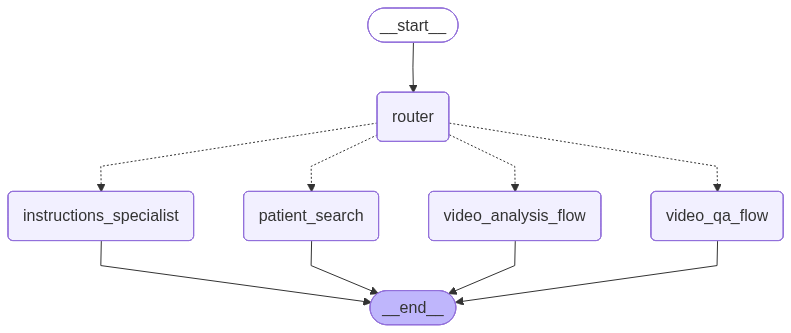

None


In [8]:
show_graph_structure(demo_graph_v2)
print(current_state["active_patient_context"])


## Flow 1: instructions

Run an instructions-oriented question first. The returned state becomes the input for the next flow.


In [9]:
instructions_question = "How should I describe my symptoms so this assistant can help me better?"

current_state = invoke_cumulative_turn(
    demo_graph_v2,
    current_state,
    instructions_question,
)

state_json = json.dumps(describe_state(current_state), ensure_ascii=False, indent=2)
display(Markdown(f"```json\n{state_json}\n```"))



Router response: destination='instructions_specialist' rationale='The user is asking for guidance on how to describe their symptoms, which falls under using the assistant effectively.'


```json
{
  "active_patient": null,
  "route": "instructions_specialist",
  "router_rationale": "The user is asking for guidance on how to describe their symptoms, which falls under using the assistant effectively.",
  "route_history": [
    "instructions_specialist"
  ],
  "message_count": 2,
  "video_path": null,
  "video_artifact_dir": null,
  "video_id": null,
  "has_video_analysis_result": false,
  "final_answer": "To help the assistant understand your symptoms better, provide these key details:\n\n1. **Age Range**: Mention if you're a child, teenager, adult, or elderly.\n2. **Timeline**: When did the symptoms start? Are they new or have they been ongoing?\n3. **Severity**: How severe are the symptoms? Use terms like mild, moderate, or severe.\n4. **Triggers**: What seems to trigger or worsen your symptoms?\n5. **Associated Symptoms**: List any other symptoms you might be experiencing.\n6. **Medical History**: Include any relevant past illnesses or conditions.\n7. **Video**: If available, share a video of yourself describing the symptoms.\n\nThis information will help the assistant give you more accurate and helpful advice."
}
```

In [10]:
pretty_print_latest_state_messages(current_state, "After Flow 1: instructions_specialist")



=== After Flow 1: instructions_specialist ===
Showing latest 2 message(s) from 2 total.

--- Latest message 1/2 ---
================================ Human Message =================================

How should I describe my symptoms so this assistant can help me better?

--- Latest message 2/2 ---
================================== Ai Message ==================================

To help the assistant understand your symptoms better, provide these key details:

1. **Age Range**: Mention if you're a child, teenager, adult, or elderly.
2. **Timeline**: When did the symptoms start? Are they new or have they been ongoing?
3. **Severity**: How severe are the symptoms? Use terms like mild, moderate, or severe.
4. **Triggers**: What seems to trigger or worsen your symptoms?
5. **Associated Symptoms**: List any other symptoms you might be experiencing.
6. **Medical History**: Include any relevant past illnesses or conditions.
7. **Video**: If available, share a video of yourself describing the s

## Flow 2: patient search

Load a different synthetic patient into the same cumulative state.


In [11]:
patient_search_question = "Load the patient profile for Maria S."

current_state = invoke_cumulative_turn(
    demo_graph_v2,
    current_state,
    patient_search_question,
)

state_json = json.dumps(describe_state(current_state), ensure_ascii=False, indent=2)
display(Markdown(f"```json\n{state_json}\n```"))


Router response: destination='patient_search' rationale='The user wants to load a specific patient profile.'


```json
{
  "active_patient": "Maria S.",
  "route": "patient_search",
  "router_rationale": "The user wants to load a specific patient profile.",
  "route_history": [
    "instructions_specialist",
    "patient_search"
  ],
  "message_count": 4,
  "video_path": null,
  "video_artifact_dir": null,
  "video_id": null,
  "has_video_analysis_result": false,
  "final_answer": "The patient profile for Maria S. has been successfully loaded into notebook state."
}
```

In [12]:
pretty_print_latest_state_messages(current_state, "After Flow 2: patient_search")



=== After Flow 2: patient_search ===
Showing latest 2 message(s) from 4 total.

--- Latest message 1/2 ---
================================ Human Message =================================

Load the patient profile for Maria S.

--- Latest message 2/2 ---
================================== Ai Message ==================================

The patient profile for Maria S. has been successfully loaded into notebook state.


## Flow 3: real video analysis

Run the real `video_pipeline` against the local video. The result is stored in the same cumulative state.


In [13]:
DEFAULT_VIDEO_PATH = Path("concepts_video/input_videos/abuse_with_audio.mp4")
DEFAULT_VIDEO_ARTIFACT_DIR = Path("concepts_video/outputs/langgraph_router_video_v2")

video_analysis_question = "Process this local video file with the real video pipeline."

current_state = invoke_cumulative_turn(
    demo_graph_v2,
    current_state,
    video_analysis_question,
    video_path=str(DEFAULT_VIDEO_PATH),
    video_artifact_dir=str(DEFAULT_VIDEO_ARTIFACT_DIR),
)

state_json = json.dumps(describe_state(current_state), ensure_ascii=False, indent=2)
display(Markdown(f"```json\n{state_json}\n```"))


Router response: destination='video_analysis_flow' rationale='The user wants to analyze and process a video file using the pipeline.'



100%|██████████| 1001/1001 [00:02<00:00, 495.77frames/s]


```json
{
  "active_patient": "Maria S.",
  "route": "video_analysis_flow",
  "router_rationale": "The user wants to analyze and process a video file using the pipeline.",
  "route_history": [
    "instructions_specialist",
    "patient_search",
    "video_analysis_flow"
  ],
  "message_count": 6,
  "video_path": "concepts_video\\input_videos\\abuse_with_audio.mp4",
  "video_artifact_dir": "concepts_video\\outputs\\langgraph_router_video_v2",
  "video_id": "abuse_with_audio",
  "has_video_analysis_result": true,
  "final_answer": "Video analysis complete. The real video_pipeline result is now stored in state.\n\nVideo Analysis Summary:\n- Video ID: abuse_with_audio\n- Duration: 10.0s\n- Transcript:\n  Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior. Eu tenho medo, isso já acontece há muito tempo.\n- Transcript segments:\n  [0.0s - 5.9s] Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior.\n  [5.9s - 9.1s] Eu tenho medo, isso já acontece há muito tempo.\n- Dominant expressions:\n  [0.0s - 8.0s] neutral_expression (score: 0.77)\n  [5.0s - 10.0s] neutral_expression (score: 0.76)\n- Posture observations:\n  [0.0s - 8.0s] hand_on_neck (score: 1.00)\n  [5.0s - 10.0s] hand_on_neck (score: 1.00)\n\nArtifacts written to: C:\\Users\\LuizAlbertodeAndrade\\source\\repos\\screening_robot\\concepts_video\\outputs\\langgraph_router_video_v2"
}
```

In [14]:
pretty_print_latest_state_messages(current_state, "After Flow 3: video_analysis_flow")



=== After Flow 3: video_analysis_flow ===
Showing latest 2 message(s) from 6 total.

--- Latest message 1/2 ---
================================ Human Message =================================

Process this local video file with the real video pipeline.

--- Latest message 2/2 ---
================================== Ai Message ==================================

Video analysis complete. The real video_pipeline result is now stored in state.

Video Analysis Summary:
- Video ID: abuse_with_audio
- Duration: 10.0s
- Transcript:
  Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior. Eu tenho medo, isso já acontece há muito tempo.
- Transcript segments:
  [0.0s - 5.9s] Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior.
  [5.9s - 9.1s] Eu tenho medo, isso já acontece há muito tempo.
- Dominant expressions:
  [0.0s - 8.0s] neutral_expression (score: 0.77)
  [5.0s - 10.0s] neutral_expression (score: 0.76)
- Posture observa

## Flow 4: clinical video QA

Ask a clinical question about the patient and the already processed video. This is the only flow rendered by `clinical_llm`.


In [15]:
video_qa_question = "Com base no paciente e no vídeo analisado, apresente uma avaliação clínica cautelosa."

current_state = invoke_cumulative_turn(
    demo_graph_v2,
    current_state,
    video_qa_question,
)

state_json = json.dumps(describe_state(current_state), ensure_ascii=False, indent=2)
display(Markdown(f"```json\n{state_json}\n```"))


Router response: destination='video_qa_flow' rationale='A frase pede uma avaliação clínica baseada em um paciente e um vídeo analisado, o que se encaixa na categoria de perguntas sobre um vídeo já processado.'


```json
{
  "active_patient": "Maria S.",
  "route": "video_qa_flow",
  "router_rationale": "A frase pede uma avaliação clínica baseada em um paciente e um vídeo analisado, o que se encaixa na categoria de perguntas sobre um vídeo já processado.",
  "route_history": [
    "instructions_specialist",
    "patient_search",
    "video_analysis_flow",
    "video_qa_flow"
  ],
  "message_count": 8,
  "video_path": "concepts_video\\input_videos\\abuse_with_audio.mp4",
  "video_artifact_dir": "concepts_video\\outputs\\langgraph_router_video_v2",
  "video_id": "abuse_with_audio",
  "has_video_analysis_result": true,
  "final_answer": "**Avaliação clínica cautelosa (com base no contexto do paciente e no vídeo analisado)**  \n\n| Tempo (s) | Conteúdo verbal | Expressões faciais predominantes | Postura observada | Observações clínicas |\n|-----------|-----------------|----------------------------------|-------------------|----------------------|\n| 0 – 5.9 | “Eu não sei mais o que fazer, ele me bate e diz que contar para alguém vai ser pior.” | Neutro (score 0.77) com presença de **sorriso triste** (score 0.64) e **medo** (score 0.62). | **Mão na nuca** (score 1.00) + **mão no peito** (score 1.00) + cabeça ligeiramente inclinada para frente. | Indica tensão física e emocional; a expressão “sorriso triste” sugere tentativa de mascarar ou minimizar a dor. A postura de “mão na nuca” pode indicar tensão muscular ou tentativa de proteger a cabeça. |\n| 5.9 – 9.1 | “Eu tenho medo, isso já acontece há muito tempo.” | Neutro (score 0.76) com **sorriso triste** (score 0.65) e **medo** (score 0.63). | Mesma postura de “mão na nuca” + “mão no peito”. | A repetição da frase de medo reforça a percepção de perigo contínuo. A postura permanece constante, sugerindo que a paciente está em estado de alerta. |\n\n### Síntomas observados\n1. **Anxiety / medo** – Evidenciado verbalmente e por expressões faciais de medo.  \n2. **Sofrimento emocional** – Sorriso triste e postura de tensão indicam sofrimento interno.  \n3. **Possível violência doméstica** – Declaração explícita de agressão física (“ele me bate”) e medo de denunciar.  \n4. **Sintomas de estresse pós‑traumático** – Repetição de eventos traumáticos (“já acontece há muito tempo”) e postura de alerta constante.  \n5. **Distúrbios do sono** – Relatado no contexto clínico, embora não diretamente observado no vídeo, pode estar relacionado ao medo e à ansiedade.\n\n### Incertezas e limitações\n- O vídeo tem apenas 10 s; não há informação sobre a frequência ou intensidade das agressões.  \n- A expressão dominante é neutra; pode haver sub‑expressões que não foram capturadas.  \n- Não há dados sobre a presença de ferimentos físicos visíveis.  \n- Não há confirmação de que a situação descrita seja atual ou que a paciente esteja em risco imediato de violência.\n\n### Perguntas de seguimento recomendadas\n1. **Segurança imediata**: Você se sente em perigo no momento? Há alguém em quem confie que possa ajudá-la?  \n2. **Rede de apoio**: Você tem amigos, familiares ou colegas que possam oferecer suporte?  \n3. **Histórico de violência**: Há quanto tempo a agressão ocorre? Já procurou ajuda antes?  \n4. **Saúde física**: Você percebe ferimentos ou dores que não foram mencionados?  \n5. **Saúde mental**: Como tem sido seu sono? Você já tentou técnicas de relaxamento ou terapia?  \n6. **Medicação**: Está usando algum medicamento além do albuterol?  \n\n### Recomendações de ação\n- **Planejamento de segurança**: Se houver risco imediato, considerar contato com serviços de emergência (112) ou com a delegacia de violência doméstica.  \n- **Suporte psicológico**: Encaminhar para psicoterapia especializada em violência doméstica e ansiedade.  \n- **Avaliação médica**: Exame físico para identificar possíveis lesões e avaliar a necessidade de cuidados médicos.  \n- **Apoio social**: Orientar a paciente a buscar grupos de apoio a vítimas de violência doméstica e a serviços de assistência social.  \n- **Monitoramento**: Agendar consultas de acompanhamento para avaliar evolução do medo, ansiedade e sono.  \n\n> **Nota de cautela**: Esta avaliação não substitui uma consulta presencial. Se a paciente sentir que está em perigo imediato, procure ajuda de emergência ou entre em contato com serviços de apoio a vítimas de violência doméstica."
}
```

In [16]:
pretty_print_latest_state_messages(current_state, "After Flow 4: video_qa_flow")



=== After Flow 4: video_qa_flow ===
Showing latest 2 message(s) from 8 total.

--- Latest message 1/2 ---
================================ Human Message =================================

Com base no paciente e no vídeo analisado, apresente uma avaliação clínica cautelosa.

--- Latest message 2/2 ---
================================== Ai Message ==================================

**Avaliação clínica cautelosa (com base no contexto do paciente e no vídeo analisado)**  

| Tempo (s) | Conteúdo verbal | Expressões faciais predominantes | Postura observada | Observações clínicas |
|-----------|-----------------|----------------------------------|-------------------|----------------------|
| 0 – 5.9 | “Eu não sei mais o que fazer, ele me bate e diz que contar para alguém vai ser pior.” | Neutro (score 0.77) com presença de **sorriso triste** (score 0.64) e **medo** (score 0.62). | **Mão na nuca** (score 1.00) + **mão no peito** (score 1.00) + cabeça ligeiramente inclinada para frente. | I

## Final state inspection

These cells verify the route order and show the final video JSON stored in state.


In [19]:
expected_route_history = [
    "instructions_specialist",
    "patient_search",
    "video_analysis_flow",
    "video_qa_flow",
]

actual_route_history = current_state.get("route_history") or []

route_history_check = {
    "expected_route_history": expected_route_history,
    "actual_route_history": actual_route_history,
    "matches_expected": actual_route_history == expected_route_history,
}

state_json = json.dumps(route_history_check, ensure_ascii=False, indent=2)
display(Markdown(f"```json\n{state_json}\n```"))


```json
{
  "expected_route_history": [
    "instructions_specialist",
    "patient_search",
    "video_analysis_flow",
    "video_qa_flow"
  ],
  "actual_route_history": [
    "instructions_specialist",
    "patient_search",
    "video_analysis_flow",
    "video_qa_flow"
  ],
  "matches_expected": true
}
```

In [18]:
if current_state.get("video_analysis_result") is None:
    print("No video_analysis_result is present in state.")
else:
    display(Markdown(
        "```json\n"
        + current_state["video_analysis_result"].model_dump_json(indent=2)
        + "\n```"
    ))


```json
{
  "video_id": "abuse_with_audio",
  "duration_s": 10.0,
  "window_s": 8.0,
  "stride_s": 5.0,
  "expression": {
    "module": "expression",
    "windows": [
      {
        "start_s": 0.0,
        "end_s": 8.0,
        "detections": [
          {
            "label": "neutral_expression",
            "score": 0.772,
            "support": 0.513
          },
          {
            "label": "sad_expression",
            "score": 0.638,
            "support": 0.301
          },
          {
            "label": "fear_expression",
            "score": 0.623,
            "support": 0.119
          },
          {
            "label": "surprise_expression",
            "score": 0.783,
            "support": 0.057
          },
          {
            "label": "joy_expression",
            "score": 0.734,
            "support": 0.005
          },
          {
            "label": "anger_expression",
            "score": 0.325,
            "support": 0.005
          }
        ],
        "dominant": {
          "label": "neutral_expression",
          "score": 0.772
        }
      },
      {
        "start_s": 5.0,
        "end_s": 10.0,
        "detections": [
          {
            "label": "neutral_expression",
            "score": 0.764,
            "support": 0.45
          },
          {
            "label": "sad_expression",
            "score": 0.651,
            "support": 0.392
          },
          {
            "label": "fear_expression",
            "score": 0.63,
            "support": 0.1
          },
          {
            "label": "surprise_expression",
            "score": 0.788,
            "support": 0.058
          }
        ],
        "dominant": {
          "label": "neutral_expression",
          "score": 0.764
        }
      }
    ]
  },
  "pose": {
    "module": "pose",
    "windows": [
      {
        "start_s": 0.0,
        "end_s": 8.0,
        "detections": [
          {
            "label": "hand_on_neck",
            "score": 1.0,
            "support": 0.897
          },
          {
            "label": "hand_on_chest",
            "score": 1.0,
            "support": 0.897
          },
          {
            "label": "forward_head",
            "score": 0.531,
            "support": 1.0
          }
        ],
        "dominant": {
          "label": "hand_on_neck",
          "score": 1.0
        }
      },
      {
        "start_s": 5.0,
        "end_s": 10.0,
        "detections": [
          {
            "label": "hand_on_neck",
            "score": 1.0,
            "support": 0.792
          },
          {
            "label": "hand_on_chest",
            "score": 1.0,
            "support": 0.792
          },
          {
            "label": "forward_head",
            "score": 0.531,
            "support": 1.0
          }
        ],
        "dominant": {
          "label": "hand_on_neck",
          "score": 1.0
        }
      }
    ]
  },
  "transcription": {
    "module": "transcription",
    "language": "pt",
    "text": "Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior. Eu tenho medo, isso já acontece há muito tempo.",
    "segments": [
      {
        "start": 0.0,
        "end": 5.88,
        "text": "Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior."
      },
      {
        "start": 5.88,
        "end": 9.12,
        "text": "Eu tenho medo, isso já acontece há muito tempo."
      }
    ],
    "has_audio": true
  }
}
```